# Normalize Total Gradient (NTG) for Aerial Image Registration
## Aberrations Complete [Translation & Zoom] (v2 - Joint Scale + Translation)

**Cambio de estructura respecto a v1:** la escala ya no se estima asumiendo `tx = ty = 0`. En el nivel grueso se hace un
*barrido conjunto* (template matching multiescala por NCC [Normalized Cross Correlation] enmascarada + FFT [Fast Fourier Transform]): para cada escala `s` la traslación óptima se resuelve
de forma exacta, y el pico de correlación en función de `s` indica la escala. Los mejores candidatos se refinan con NTG nivel a nivel
(coarse-to-fine real) y gana el de menor NTG.

### LIBRERIAS PARA LA IMPLEMENTACIÓN

In [1]:
## ----- Librerías Principales - Módulo para manejo de imágen y visualización ------ ##

import cv2                                            # Librería - OpenCV: Carga, procesamiento y manipulación de imágenes y video.
import numpy as np                                    # Librería - NumPy: Operaciones matriciales, vectores y cálculo numérico de alto rendimiento.
import matplotlib.pyplot as plt                       # Librería - Matplotlib: Visualización de gráficos, curvas y renderizado de imágenes 
                                                      #            (NOTA: para tiempo real no es recomendable).


## ----- SciPy - Módulo de optimización numérica ------ ##

from scipy.optimize import differential_evolution     # Algoritmo genético/estocástico para optimización global 
from scipy.optimize import minimize                   # Métodos de optimización local (ej. Nelder-Mead, BFGS, Powell)

## ----- SciPy - Módulo de análisis de señales y frecuencia ----- ##

from scipy import fft as sp_fft                       # Transformada Rápida de Fourier (FFT) para filtrado y análisis espectral

### CARGA DE IMAGENES [RGB & NIR]

In [2]:
ti = 1 # Definimos el total de imagenes a trabajar [de 1 a 185 tomando al dataset de base]

## ----- Inicialización de listas para almacenar las imagenes RGB y NIR ----- ##

img_BGR = []                # Lista de imagenes BGR (formato base de visualización en OpenCV)
img_NIR = []                # Lista de imagenes NIR (espectro Infrarrojo Cercano)
img_RGB = []                # Lista de imagenes RGB (conversión de formato BGR para visualización de color apropiada)
img_RGBgray = []            # Lista de imagenes RGB en grayscale (usado para aplicar operaciones de Image Registration)

## ----- Carga de imagenes del dataset y operaciones sobre ellas (aberraciones,conversiones,Image Registration,etc.) ----- ## {n:03d}
for n in range(1):
    bgr = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Sat_images/Photos_2018/GC_019.png')
    ir = cv2.imread(f'/Users/Alex/Documents/Dataset_Vegetation_Final_Version/Additional_data/Infrared_images/Infrared_2018/GC_019_Infrarred.png',cv2.IMREAD_GRAYSCALE)

    # Verificación de carga de imagenes para informar de errores
    
    if bgr is None or ir is None:
        print(f'Error al cargar la imagen {n}')
        continue

    ## ----- Conversiones de formato ----- ##
    rgb = cv2.cvtColor(bgr,cv2.COLOR_BGR2RGB)          # Conversión de BGR a RGB
    rgb_gray = cv2.cvtColor(rgb,cv2.COLOR_RGB2GRAY)    # Conversión de RGB a Grayscale

    ## ----- Guardar la imagenes en sus respectivas listas ----- ##
    img_BGR.append(bgr)                                # Agregar las imagenes BGR a la lista
    img_RGB.append(rgb)                                # Agregar las imagenes RGB a la lista
    img_NIR.append(ir)                                 # Agregar las imagenes NIR a la lista
    img_RGBgray.append(rgb_gray)                       # Agregar las imagenes RGB en grayscale a la lista


### GENERACIÓN DE ABERRACIONES [TRASLACIÓN EN NIR | ZOOM EN RGB] 

#### ABERRACIÓN - Traslación

In [3]:
#### ========== GENERADOR DE ABERRACIONES - TRASLACIÓN XY ========== ####
def traslation_img (img,trans_x,trans_y):
    
    h_img, w_img = img.shape[:2]                                        # Obtenemos las dimensiones de la imagen original

    tras_x = trans_x                                                    # Pixeles de desplazamiento en x (+ derecha, - izquierda)
    tras_y = trans_y                                                    # Pixeles de desplazamiento en y (+ abajo, - arriba)
    
    m_translation = np.float32([[1,0,tras_x],[0,1,tras_y]])             # Matriz de traslación 

    translation_img = cv2.warpAffine(img,m_translation,(w_img,h_img))   # Generamos la imagen con traslación deseada

    return translation_img 

In [4]:
img_NIR_translation = []                                                # Lista para almacenar las traslaciones aplicadas sobre la imagen NIR

tras_x = +250                                                           # Factor de traslación aplicada en X [en pixeles]
tras_y = +250                                                           # Factor de traslación aplicada en Y [en pixeles]

## ----- Ciclo FOR para aplicar aberraciones en NIR y almacenarlas ----- ##
for n in range(len(img_RGB)):                                           

    img_NIR_trans = traslation_img(img_NIR[n],tras_x,tras_y)            # Aplicamos la función de traslación a la imágen NIR
    img_NIR_translation.append(img_NIR_trans)                           # Guardamos la imagen NIR con traslación 

#### ABERRACIÓN - Zoom

In [5]:
#### ========== GENERADOR DE ABERRACIONES - ZOOM ISOTRÓPICO [centrado] ========== ####
def zoom_cv(img,zoom_factor):
    
    h, w = img.shape[:2]                                                   # Obtenemos las dimensiones de la imagen original

    if zoom_factor <= 0 or zoom_factor <= 1:                               # CASO BASE: Si se coloca un valor menor a 0 o igual a 1, 
        return img                                                         #            regresa la imagen original

    # ----- Dimensiones de la región central a recortar ----- #
    new_w = int(w/zoom_factor)                                        
    new_h = int(h/zoom_factor)                                         

    # ----- Coordenadas del área de interés (ROI) centrado ----- #
    x1 = int((w - new_w) / 2)
    y1 = int((h - new_h) / 2)
    x2 = x1 + new_w
    y2 = y1 + new_h

    crop_zoom = img[y1:y2, x1:x2]                                           # Recorte del área central

    img_zoom = cv2.resize(crop_zoom,(w,h),interpolation=cv2.INTER_CUBIC)    # Reescalado al tamaño original de la image
 
    return img_zoom 

In [6]:
zoom_img_list = []                                                          # Lista para almacenar los zooms aplicados sobre la imagen RGB
zoom_imgGRAY_list = []                                                      # Lista para almacenar los zooms aplicados sobre la imagen RGB - [Usado
                                                                            #           para visualización de superposición y analisis comparativos]


zoom_factor = 1.0                                                           # Factor de zoom a aplicar en la imagen RGB

## ----- Ciclo FOR para aplicar aberraciones en RGB y almacenarlas ----- ##
for n in range(len(img_RGB)):

    zoom_img = zoom_cv(img_RGB[n],zoom_factor)                              # Aplicamos la función de zoom a la imágen RGB
    gray_zoom = cv2.cvtColor(zoom_img.copy(),cv2.COLOR_RGB2GRAY)            # Convertimos la imagen con zoom a escala de grises
    
    zoom_img_list.append(zoom_img)                                          # Guardamos la imagen RGB con zoom
    zoom_imgGRAY_list.append(gray_zoom)                                     # Guardamos la imagen RGB en escala de grises con zoom

### VISUALIZACIÓN [RGB, IR & ABERRACIONES]

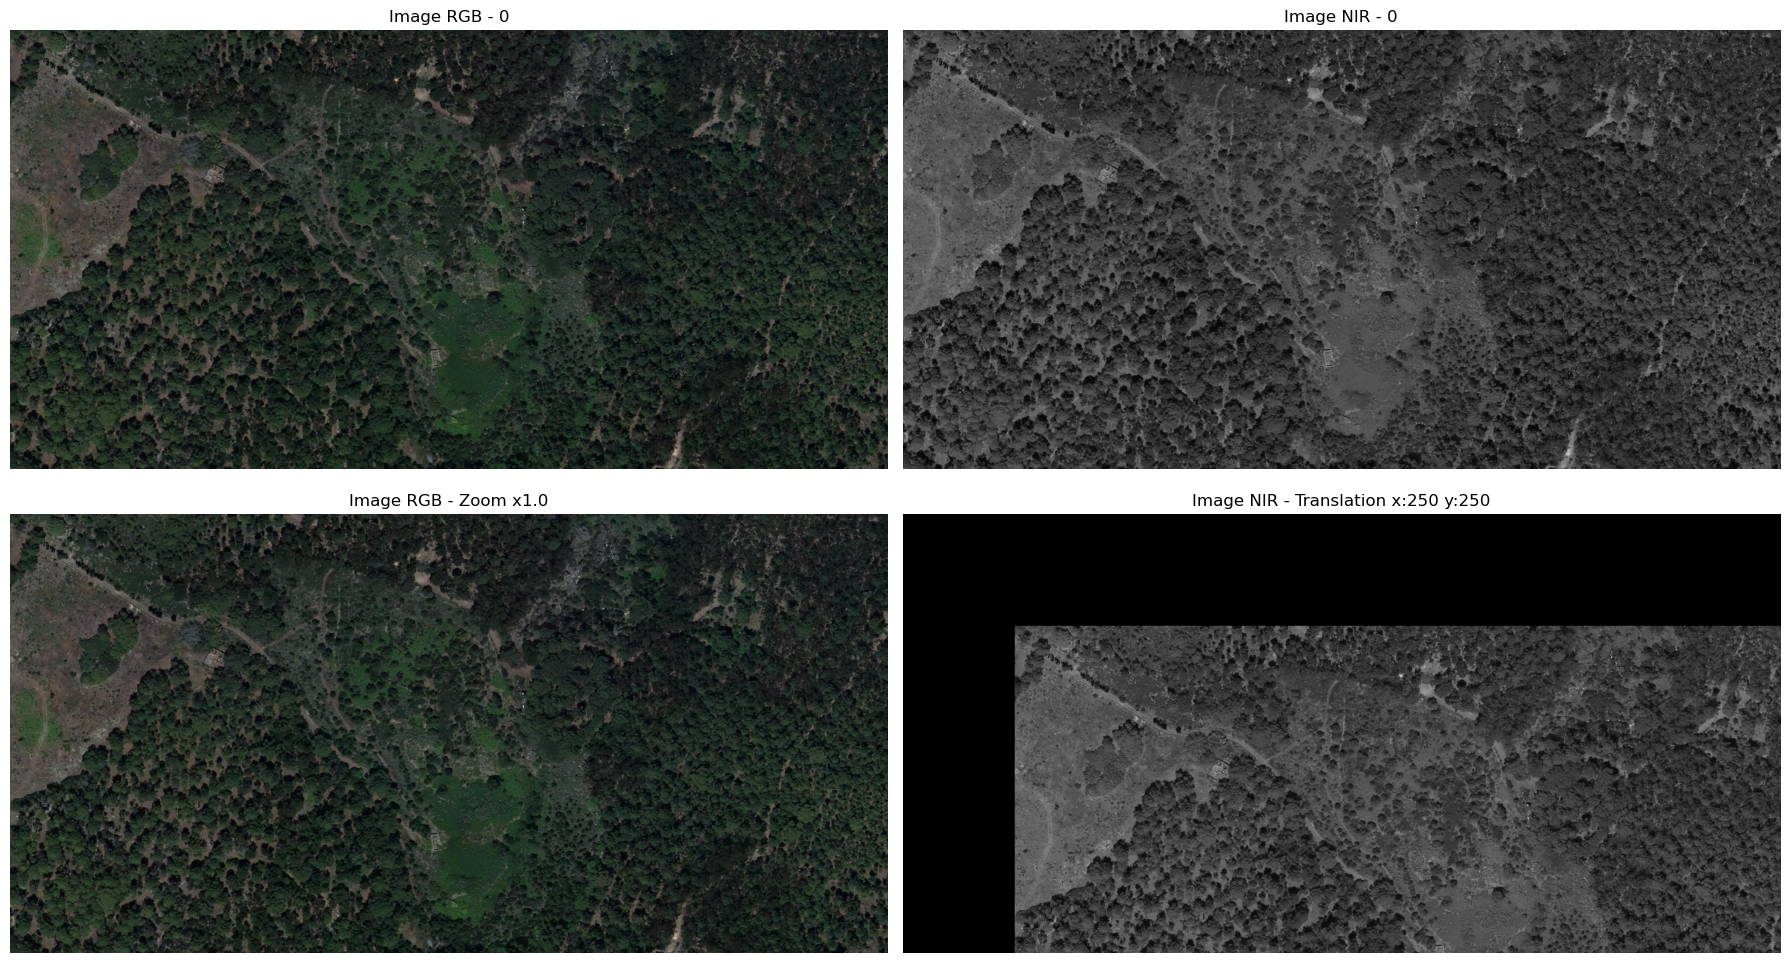

In [7]:
## ----- Ciclo FOR para para visualizar las imágenes RGB y NIR originales y sus aberraciones ----- ##
for n in range(len(img_RGB)):
    
    plt.figure(figsize=(18,10))

    # ----- SUBPLOT 1 - Imagen RGB [original] ----- #
    plt.subplot(2,2,1)
    plt.title(f"Image RGB - {n}")
    plt.imshow(img_RGB[n])
    plt.axis('off')

    # ----- SUBPLOT 2 - Imagen NIR [original] ----- #
    plt.subplot(2,2,2)
    plt.title(f"Image NIR - {n}")
    plt.imshow(img_NIR[n],cmap='gray')
    plt.axis('off')

    # ----- SUBPLOT 3 - Imagen RGB [con zoom] ----- #
    plt.subplot(2,2,3)
    plt.title(f"Image RGB - Zoom x{zoom_factor}")
    plt.imshow(zoom_img_list[n])
    plt.axis('off')

    # ----- SUBPLOT 4 - Imagen NIR [con traslación] ----- #
    plt.subplot(2,2,4)
    plt.title(f"Image NIR - Translation x:{tras_x} y:{tras_y}")
    plt.imshow(img_NIR_translation[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()

### NTG for AERIAL IMAGE REGISTRATION (Final function v0 - joint scale + translation)

Diseño de la función de registro de imágenes aéreas `(RGB y NIR)` ajustando escala e isométrica mediante una estrategia multiescala `(Coarse-to-Fine)` con NTG `(Normalized Total Gradient)` y correlación cruzada enmascarada `(Masked NCC)` usando FFT `(Fast Fourier Transform)`.

In [15]:
def aerial_ImgReg_w_NTG_v0(img_RGB,                # Imagen de referencia en formato RGB (3 canales).
                           img_NIR,                # Imagen flotante a registrar en formato NIR (1 canal).

                            # -- Tamaño de la piramide -- #
                           
                            levels,                # Número de niveles para la pirámide de resolución.

                            # -- Factor de escala -- #
                           
                            scale_factor,          # Factor de reducción de escala entre niveles adyacentes de la pirámide.

                            # -- Barrido conjunto Escala + Traslación (nivel grueso) -- #
                           
                            scale_bounds,          # Rango de búsqueda de escala global (min_scale, max_scale).
                            scale_samples,         # Número de muestras de escala a evaluar en el barrido inicial.
                            scan_blur,             # Sigma para el suavizado Gaussiano antes de calcular gradientes en el barrido inicial.
                            scan_template_min,     # Dimensión mínima en píxeles permitida para la plantilla en el barrido inicial.
                            scan_min_overlap,      # Fracción mínima de área de traslape requerida durante el barrido inicial.

                            # -- Candidatos -- #
                           
                            topk_candidates,       # Número de mejores candidatos iniciales a seleccionar tras el barrido.
                            prune_ratio,           # Tolerancia de descarte para el recorte de los peores candidatos respecto al mejor score NTG.

                            # -- Refinamiento NTG por niveles -- #
                           
                            local_population,      # Tamaño de población para el algoritmo de Evolución Diferencial en refinamiento local.
                            local_generations,     # Número máximo de iteraciones/generaciones para Evolución Diferencial.
                            local_scale_rel,       # Variación relativa permitida para el parámetro de escala durante la optimización local.
                            delta_translation,     # Radio máximo de ajuste de traslación (en píxeles) en la optimización local.

                            # -- Overlap y máscara válida -- #
                           
                            min_overlap,           # Área de traslape mínima aceptable para calcular la métrica NTG.
                            valid_erode,           # Radio de erosión para suavizar y contraer las máscaras de regiones válidas.

                            seed                   # Radio de erosión para suavizar y contraer las máscaras de regiones válidas.
                           ):

    
    #### ============================================================================= ####
    ##                     FUNCIONES PARA IMAGE REGITRATION POR NTG                      ##
    #### ============================================================================= ####

    #### ======================== FUNCIONES AUXILIARES DE PROCESAMIENTO ======================== ####

    ## ------ Calcula la derivada espacial de una imagen usando filtros separables ------##
    def spatial_derivative(img,dx,dy,ksize=3):

        kx, ky = cv2.getDerivKernels(dx,dy,ksize,normalize=True,ktype=cv2.CV_32F)  # Genera dos vectores unidimensionales para los kernels.
        derivative = cv2.sepFilter2D(img.astype(np.float32),
                                     cv2.CV_32F,kx,ky,
                                     borderType=cv2.BORDER_REFLECT101)             # Aplica el filtrado separable sobre la imagen para optimización.

        return derivative

    ## ------ Obtiene las componentes x e y del gradiente espacial ------ ##
    def compute_gradients(img):

        fx = spatial_derivative(img,dx=1,dy=0,ksize=3)     # Componente X del gradiente (derivada horizontal).
        fy = spatial_derivative(img,dx=0,dy=1,ksize=3)     # Componente Y del gradiente (derivada vertical).

        return fx, fy

    #### ======================== TRANSFORMACIONES GEOMÉTRICAS Y MÁSCARAS ======================== ####

    ## ------ Convierte parámetros de similitud (s, tx, ty) a un vector de parámetros afines ------ ##
    def similarity_to_affine_params(img,scale,tx,ty):

        H, W = img.shape[:2]                              # Obtenemos las dimensiones de la imagen de referencia [RGB].

        cx = (W - 1) / 2.0                                # Cálcula las coordenadas del centro geométrico de la imagen - CX.
        cy = (H - 1) / 2.0                                # Cálcula las coordenadas del centro geométrico de la imagen - CY.

        p = np.array([scale, 0.0, cx*(1.0 - scale) + tx,
                      0.0, scale, cy*(1.0 - scale) + ty],
                      dtype=np.float64)                   # Construye el vector de los componentes de la transformación afin.

        return p

    ## ------ Escala la traslación entre diferentes niveles de resolución de la pirámide ------ ##
    def transfer_similarity_between_levels(q,from_level,to_level,scale_factor=2.0):

        factor = scale_factor**(to_level - from_level)    # Cálcula el factor que relaciona los pixeles del nivel de origen al destino.

        return np.array([q[0],q[1]*factor,q[2]*factor],dtype=np.float64)

    ## ------ Aplica una transformación rápida por similitud usando WarpAffine ------ ##
    def warp_similarity(img,s,tx,ty):

        H, W = img.shape[:2]                              # Obtenemos las dimensiones de la imagen flotante [NIR].

        cx = (W - 1) / 2.0                                # Cálcula las coordenadas del centro geométrico de la imagen - CX.
        cy = (H - 1) / 2.0                                # Cálcula las coordenadas del centro geométrico de la imagen - CY.

        M = np.float32([[s,0,cx*(1-s) + tx],
                        [0,s,cy*(1-s) + ty]])             # Construye la matriz de transformación afín.

        return cv2.warpAffine(img,M,(W,H),flags=cv2.INTER_LINEAR | cv2.WARP_INVERSE_MAP,
                              borderMode=cv2.BORDER_CONSTANT,borderValue=0)

    ## ------ Máscara de contenido válido de la imagen NIR (elimina franjas negras resultantes de la traslación) ------ ##
    def estimate_valid_mask(img):

        zero = (img == 0).astype(np.uint8)                                  # Máscara binaria para marcar pixeles vacíos con 1 y el resto con 0.
        n_labels, labels = cv2.connectedComponents(zero,connectivity=4)     # Identifica regiones continuas (4 vecinos minimamente) con información. 

        valid = np.ones(img.shape[:2],dtype=np.float32)                     # Inicialización de la máscara de salida con valor igual a 1.

        border_labels = set(np.unique(np.concatenate([labels[0],labels[-1],
                                                      labels[:,0],labels[:,-1]]))) - {0} # Se invalidan las regiones de ceros conectadas con el borde de la imagen

        for label in border_labels:

            region = (labels == label)         # Se trabaja únicamente con los pixeles que coincidan con la región de trabajo actual.

            if region.sum() > 50:              # Filtramos ruido diminuto que pueda parecer pixeles de información inválida. 
                valid[region] = 0.0            # En caso de cumplir con la condición anterior, se etiquetan como inválidos. 

        return valid

    ## ------ Proyecta la máscara de validez y le aplica una erosión para evitar efectos de borde ------ ##
    def warp_valid_mask(valid,s,tx,ty,erode=2):

        w = warp_similarity(valid,s,tx,ty)     # Proyecta / ajusta la máscara original en función de la similitud.
        mask = (w > 0.999).astype(np.uint8)    # Conservamos únicamente los pixeles que sean válidos.

        if erode > 0:                                                         # Comienzo del filtrado morfológico. 
            mask = cv2.erode(mask,np.ones((2*erode+1,2*erode+1),np.uint8))    # Reduce el área de la máscar binaria.

        return mask.astype(bool)

    ## ------ Calcula las matrices de mapeo u, v para operaciones de remap ------ ##
    def affine_matrix(img,identity_params):

        H, W = img.shape[:2]                             # Obtenemos las dimensiones de la imagen flotante [NIR].
        
        y, x = np.indices((H, W), dtype=np.float32)      # Generación de la cuadrícula de coordenadas (X, Y).

        p1, p2, p3, p4, p5, p6 = identity_params         # Desgloza los 6 coeficientes del vector de parámetros afínes. 

        u = (p1*x + p2*y + p3).astype(np.float32)        # Matriz de coordenadas transformadas en el eje horizontal X.
        v = (p4*x + p5*y + p6).astype(np.float32)        # Matriz de coordenadas transformadas en el eje vertical Y. 

        return u, v

    ## ------ Aplica la deformación final por mapa de coordenadas personalizadas ------ ##
    def warp_image_ntg(img,identity_params):

        u, v = affine_matrix(img,identity_params)                           # Genera las cuadriculas bidimensionales de coordenadas (u y v)

        warped = cv2.remap(img,u,v,interpolation=cv2.INTER_LINEAR,
                           borderMode=cv2.BORDER_CONSTANT,borderValue=0)    # Reestructuración espacial de los pixeles de la imagen, colocandolos
                                                                            # en la posición indicada por las matrices u y v.
        return warped

    #### ======================== MÉTRICA DE OPTIMIZACIÓN NTG ======================== ####

    ## ------ Construye la función objetivo NTG para evaluar el grado de desalineación entre las imágenes ------ ##
    def build_ntg(img_reference,img_floating,valid):

        ref_gx, ref_gy = compute_gradients(img_reference)        # Cálcula y almacena las derivadas espaciales X e Y. 
        flo = img_floating.astype(np.float32)                    # Conversión de la imágen flotante [NIR] a formato float32. 


        ## ------ Evalúa el grado de desalineación entre dos imágenes para una tranformación de similitud ------ ##
        def ntg_function(s,tx,ty,min_ov=0.25,return_overlap=False): 
            
            mask = warp_valid_mask(valid,s,tx,ty,valid_erode)    # Máscara booleana con la información de intersección de pixeles válidos.
            overlap_ratio = float(mask.mean())                   # Proporción de traslape efectivo entre dos imágenes.

            if overlap_ratio < min_ov:
                return (1.0,overlap_ratio) if return_overlap else 1.0  # Se penaliza las transformaciones con traslape insuficiente.

            warped = warp_similarity(flo,s,tx,ty)                # Aplica la transformación de similitud actual sobre la imagen NIR.
            warped_gx, warped_gy = compute_gradients(warped)     # Obtiene las derivadas espaciales de la imagen NIR deformada.

            a = np.sum(np.abs(ref_gx[mask])) + np.sum(np.abs(ref_gy[mask]))         # Cálcula la norma L1 de la magnitud de gradiente para la imagen RGB.
            b = np.sum(np.abs(warped_gx[mask])) + np.sum(np.abs(warped_gy[mask]))   # Cálcula la norma L1 de la magnitud de gradiente para la imagen NIR.

            if a < 1e-8 or b < 1e-8:
                return (1.0,overlap_ratio) if return_overlap else 1.0  # Evita divisiones por cero en regiones planas o sin textura.

            rx, ry = ref_gx[mask]/a, ref_gy[mask]/a              # Normalización de los campos de gradientes para reducir la interferencia en la imagen RGB.
            wx, wy = warped_gx[mask]/b, warped_gy[mask]/b        # Normalización de los campos de gradientes para reducir la interferencia en la imagen NIR.

            numerator = np.sum(np.abs(wx - rx)) + np.sum(np.abs(wy - ry))  # Cálcula la distancia L1 entre los campos de gradientes en la zona de traslape.
            denominator = (np.sum(np.abs(wx)) + np.sum(np.abs(wy)) +   
                           np.sum(np.abs(rx)) + np.sum(np.abs(ry)))        # Cálcula el factor de normalización.

            ntg = float(numerator/denominator)                   # Error NTG considerando a [0.0] como alineación perfecta y [1.0] máxima desalineación.

            return (ntg,overlap_ratio) if return_overlap else ntg

        return ntg_function

    #### ============ BARRIDO CONJUNTO ESCALA Y TRASLACIÓN (NCC por FFT) ============ ####

    ## ------ Correlación Cruzada Normalizada Enmascarada en el dominio de la frecuencia [Método Padfield] ------ ##
    def masked_ncc(f,mf,g,mg):

        Hf, Wf = f.shape                                   # Extrae la dimensión de altura (H).
        Hg, Wg = g.shape                                   # Extrae la dimensión de anchura (W).

        PH = sp_fft.next_fast_len(Hg + Hf - 1)             # Calcula el tamaño óptimo del padding en la altura para FFT.
        PW = sp_fft.next_fast_len(Wg + Wf - 1)             # Calcula el tamaño óptimo del padding en la anchura para FFT.

        F = lambda a: sp_fft.rfft2(a.astype(np.float32),(PH,PW))  # Función auxiliar para calcular FFT 2D ajustada al tamaño.
        C = lambda A,B: sp_fft.irfft2(np.conj(A)*B,(PH,PW))       # Función auxiliar para calcular correlación cruzada.

        Ff, Fmf, Ff2 = F(f), F(mf), F(f*f)                 # Transformaciones al dominio de la frecuencia [F]: imágen, máscara e intensidad. 
        Fg, Fmg, Fg2 = F(g), F(mg), F(g*g)                 # Transformaciones al dominio de la frecuencia [G]: imágen, máscara e intensidad. 

        N = C(Fmf,Fmg)                                     # Píxeles en traslape para cada desplazamiento

        Nsafe = np.maximum(N,1.0)                          # Evita divisiones por cero en áreas sin traslape. 

        numerator = C(Ff,Fg) - C(Ff,Fmg)*C(Fmf,Fg)/Nsafe       # Calcula la covarianza cruzada local enmascarada para cada desplazamiento.
        var_f = C(Ff2,Fmg) - C(Ff,Fmg)**2/Nsafe                # Calcula la varianza local de la imagen [F] restringida a la zona de traslape.
        var_g = C(Fmf,Fg2) - C(Fmf,Fg)**2/Nsafe                # Calcula la varianza local de la imagen [G] restringida a la zona de traslape.

        denominator = np.sqrt(np.maximum(var_f*var_g,1e-6))    # Calcula la desviación estandar conjunta.

        return numerator/denominator, N

    ## ------ Realiza una búsqueda global por plantilla utilizando correlación multiescala para obtener el factor de escala y la traslación ------ ##
    def joint_scale_translation_scan(img_reference_full,floating_levels,valid_levels,scales,blur,min_ov,template_min):

        Hr, Wr = img_reference_full.shape[:2]                  # Dimensiones fijas de la referencia completa. 
        W0 = floating_levels[0].shape[1]                       # Ancho del nivel base [0] de la imagen flotante [NIR].

        floating_f32 = [fl.astype(np.float32) for fl in floating_levels]  # Convierte todos los niveles de la pirámide NIR en tipo float32.

        scan = []                                              # Lista que almacenará los resultados por cada escala evaluada. 

        for s in scales:

            L = len(floating_levels) - 1                       # Establece el nivel de la pirámide, partiendo del más grueso.

            for i, fl in enumerate(floating_levels):           # Se recorre la pirámide de menor a mayor submuestreo.

                if s*fl.shape[1] >= template_min:              # Obtimización de la velocidad de cómputo al seleccionar el nivel más grueso 
                                                               # pero con menor número de pixeles.
                    L = i
                    break

            flo_L = floating_f32[L]                            # Extración de la imágen flotante del nivel L seleccionado.
            val_L = valid_levels[L]                            # Extración de la máscara de válidez del nivel L seleccionado.

            H_L, W_L = flo_L.shape[:2]                         # Extración de las dimensiones de la imagen flotante del nivel L seleccionado.

            # -- Plantilla -- #
            wt = int(round(s*W_L))    # Dimensiones enteras que tendra la plantilla (ancho) ajustadas por el factor s.
            ht = int(round(s*H_L))    # Dimensiones enteras que tendra la plantilla (alto) ajustadas por el factor s.

            if wt < 8 or ht < 8 or wt > W_L or ht > H_L:       # Filtra y descarta dimensiones inválidas.
                continue

            s_eff = wt/float(W_L)                              # Recalcular el factor de escala real.

            template = cv2.resize(img_reference_full,(wt,ht),interpolation=cv2.INTER_AREA).astype(np.float32) # Redimensionar la imagen de referencia al tamaño de la plantilla.

            tgx, tgy = compute_gradients(cv2.GaussianBlur(template,(0,0),blur))  # Aplicar un filtro Gaussiano para mitigar el ruido y cálculo del gradiente. 
            
            tmag = np.hypot(tgx,tgy)                           # Cálculo de la magnitud del gradiente de la plantilla. 

            mt = np.ones_like(tmag,dtype=np.float32)           # Define la máscara de la plantilla.
            f = tmag - tmag.mean()                             # A la máscara se le resta la magnitud del gradiente para centrarla en 0.

            lgx, lgy = compute_gradients(cv2.GaussianBlur(flo_L,(0,0),blur))  # Aplica filtro Gaussiano y calcula el gradiente sobre el lienzo del nivel L.
            
            lmag = np.hypot(lgx,lgy)                           # Obtiene la magnitud del gradiente del lienzo.

            mv = cv2.erode((val_L > 0.999).astype(np.uint8),
                           np.ones((5,5),np.uint8)).astype(np.float32)  # Genera la máscara de validez para el lienzo para eliminar inconsistencias de borde.

            mu = (lmag*mv).sum()/max(mv.sum(),1.0)             
            g = (lmag - mu)*mv                                 # Enmascarar las zonas no válidas fuera del contenido.

            r, N = masked_ncc(f,mt,g,mv)                       # Ejecuta la correlación cruzada normalizada enmascarada en el dominio de frecuencia.

            r = np.where(N >= min_ov*wt*ht,r,-1.0)             # Invalida las posiciones donde el area de traslape sea menor al umbral mínimo permitido. 

            iy, ix = np.unravel_index(np.argmax(r),r.shape)    # Encuentra las coordenadas del pico de máxima correlación dentro de la matriz se respuesta.

            dy = iy - r.shape[0] if iy >= H_L else iy     # Convierte los índices FFT a desplazamiento espacial real Dy.
            dx = ix - r.shape[1] if ix >= W_L else ix     # Convierte los índices FFT a desplazamiento espacial real Dx.

            tx_L = dx - (1.0 - s_eff)*W_L/2.0             # Convierte el desplazamiento a parámetros de traslape [dx] en el sistema de coordenadas de L.
            ty_L = dy - (1.0 - s_eff)*H_L/2.0             # Convierte el desplazamiento a parámetros de traslape [dy] en el sistema de coordenadas de L.

            to_level0 = W0/float(W_L)                     # Factor de conversión para escalar la traslación del nivel L a resolución completa.

            scan.append({"s": float(s_eff),               # Diccionario que contiene: la escala efectiva,
                         "tx": float(tx_L*to_level0),     # traslación en X,
                         "ty": float(ty_L*to_level0),     # traslación en Y,
                         "score": float(r[iy,ix]),        # score de correlación,
                         "flo_level": int(L)})            # y el nivel empleado.

        return scan

    ## ------ Filtra y selecciona los mejores candidatos con escalas distintas ------ ##
    def select_top_candidates(scan,k,min_log_sep=0.04):

        ordered = sorted(scan,key=lambda d: -d["score"])  # Ordena la lista de candidatos de mayor a menor según su correlación.
        selected = []                                     # Lista que almacenará únicamente a los candidatos que cumplan con el criterio.

        for d in ordered:                                 # Iteraciones comenzando por el de mayor puntuación.

            if all(abs(np.log(d["s"]/e["s"])) > min_log_sep for e in selected): # Evalua si el candidato actual es distinto de otros candidatos. 
                
                selected.append(d)                        # De ser distinto, este se agrega a la lista.

            if len(selected) == k:                        # Interrumpe la busqueda cuando se completa la cuota de candidatos.
                break

        return selected

    #### ======================== CONSTRUCCIÓN DE PIRÁMIDES Y OPTIMIZACIÓN LOCAL ======================== ####

    ## ------ Construye una pirámide de imágenes descendentes (de menor resolución a resolución real) ------ ##
    def build_pyramid(img,levels,scale):

        pyramid = [img]                                 # Inicializa la lista pyramid colocando de nivel 0 la resolución completa de la imágen.
        current_lv = img                                # Lista de referencia que nos permite dar seguimiento de imagen a partir de la ultima resolución calculada.

        for _ in range(levels - 1):                     # Estructura de control de iteraciones de los niveles restantes.

            new_width = current_lv.shape[1] // scale    # Calcula el ancho a partir de las dimensiones del nivel actual junto a la escala. 
            new_height = current_lv.shape[0] // scale   # Calcula el alto a partir de las dimensiones del nivel actual junto a la escala. 
 
            current_lv = cv2.resize(current_lv,(new_width,new_height),interpolation=cv2.INTER_AREA) # Actualiza el tamaño de la imagen y la referencia del nivel.
            
            pyramid.append(current_lv)                  # Añade la imagen recién reducida al final de la lista.

        return pyramid

    ## ------ Construye una pirámide NTG ordenada del nivel más pequeño al más grande ------ ##
    def build_NTG_pyramid(img,levels,scale):

        pyramid_NTG = build_pyramid(img,levels,scale)   # Genera la lista de niveles ordenados descendentemente.
        pyramid_NTG.reverse()                           # Invierte el orden de la lista de niveles.

        return pyramid_NTG

    #### ======================== REFINAMIENTO LOCAL POR NIVEL ======================== ####

    ## ------ Aplica un refinamiento local mediante Differential Evolution junto a Nelder-Mead ------ ##
    def local_similarity_refinement(ntg_function,similarity_initial,scale_rel,translation_radius,
                                    population,generations,seed,min_ov):

        s0, tx0, ty0 = [float(v) for v in similarity_initial]             # Desempaqueta y convierte los valores del vector en parámetros iniciales.

        bounds = [(s0*(1.0 - scale_rel),s0*(1.0 + scale_rel)),            # Define el espacio de busqueda alrededor de la estimación inicial de: escala,    
                  (tx0 - translation_radius,tx0 + translation_radius),    # traslación en X,
                  (ty0 - translation_radius,ty0 + translation_radius)]    # traslación en Y.

        objective = lambda q: ntg_function(q[0],q[1],q[2],min_ov=min_ov)  # Crea una función que ajusta el vector de entrada para ntg_function.

        result = differential_evolution(objective,bounds=bounds,popsize=population,maxiter=generations,
                                        polish=False,seed=seed,workers=1,updating="immediate",
                                        disp=False,x0=np.array([s0,tx0,ty0]))                  # Optimización heurística por Differential Evolution dentro de los límites.

        polish = minimize(objective,result.x,method="Nelder-Mead",
                          options={"xatol":1e-4,"fatol":1e-8,"maxiter":200}) # Aplica un refinamiento continuo usando Nelder-Mead sobre el resultado dado por DE.

        if polish.fun <= result.fun:
            q_best, ntg_best = polish.x, float(polish.fun)      # Compara los resultados de la función de costo entre la solución pulida y la original, 
                                                                # garantizando menor NTG.
        else:
            q_best, ntg_best = result.x, float(result.fun)      # Se queda con el mejor NTG tras el análisis.  

        return np.asarray(q_best,dtype=np.float64), ntg_best

    #### ================ PIPELINE COARSE-TO-FINE ================ ####

    ## ------ Pipeline jerárquico de registro de imágenes multiescala (coarse-to-fine) basado en NTG ------ ##
    def coarse2fine_NTG_similarity_pyramid(img_reference,img_floating):

        reference_pyramid = build_NTG_pyramid(img_reference,levels=levels,scale=scale_factor)        # Construye la pirámide multiresolución para las imagenes RGB de menor a mayor.
        floating_pyramid = build_NTG_pyramid(img_floating,levels=levels,scale=scale_factor)          # Construye la pirámide multiresolución para las imagenes NIR de menor a mayor.

        valid_full = estimate_valid_mask(img_floating)                                               # Estima la máscara de contenido válido de la imagen completa.
        valid_pyramid = [(v > 0.99).astype(np.float32)
                         for v in build_NTG_pyramid(valid_full,levels=levels,scale=scale_factor)]    # Ordena la pirámide desde el nivel más pequeño a resolución completa siempre que haya 
                                                                                                     # contenido válido.

        history = []               # Inicializa la lista para almacenar las métricas del algortimo NTG para analizar el desempeño. 

        #### ================ ETAPA 1 - BARRIDO CONJUNTO EN NIVEL GRUESO ================ ####

        print("\n========================================")
        print("STEP 1 - JOINT SCALE + TRANSLATION SCAN")
        print("========================================")

        ref0 = reference_pyramid[0]                                               # Almacena la imagen de referencia correspondiente al nivel 0.

        scales = np.geomspace(scale_bounds[0],scale_bounds[1],scale_samples)      # Genera una lista de factores de escala candidatos entre los límites de la imagen.

        scan = joint_scale_translation_scan(reference_pyramid[-1],floating_pyramid,
                                            valid_pyramid,scales,blur=scan_blur,
                                            min_ov=scan_min_overlap,
                                            template_min=scan_template_min)       # Escaneo de MNCC con contraste entre la imagen NIR contra la RGB en múltiples escalas.

        candidates = select_top_candidates(scan,topk_candidates)                  # Filtra los resultados de la busqueda seleccionando aquellos con mejores hipótesis.

        print(f"Level 0 resolution: {ref0.shape}")

        for i, c in enumerate(candidates):                                        # Imprime la lista de candidatos a optimizar.
            print(f"Candidate {i}: s={c['s']:.6f} tx={c['tx']:8.3f} ty={c['ty']:8.3f} | NCC={c['score']:.5f} | NIR level={c['flo_level']}")

        history.append({"stage": "scan",
                        "scan": scan,
                        "candidates": [dict(c) for c in candidates]})             # Registra los datos de la fase de escaneo en el historial. 

        #### ================ ETAPA 2 - REFINAMIENTO NTG NIVEL A NIVEL ================ ####

        active = [{"id": i,
                   "q": np.array([c["s"],c["tx"],c["ty"]],dtype=np.float64),
                   "q_initial": np.array([c["s"],c["tx"],c["ty"]],dtype=np.float64),
                   "ntg": np.inf} for i, c in enumerate(candidates)]              # Estructurar la lista de candidatos a optimizar, 
                                                                                  # inicializando sus vectores de trasnformación y NTG.

        for level in range(levels):

            print("\n========================================")
            print(f"LEVEL {level} - CANDIDATE REFINEMENT")
            print("========================================")

            ref_level = reference_pyramid[level]            # Recupera la imagen del nivel actual de la pirámide RGB.
            flo_level = floating_pyramid[level]             # Recupera la imagen del nivel actual de la pirámide NIR.

            print("Resolution:", ref_level.shape)         

            ntg_function = build_ntg(ref_level,flo_level,valid_pyramid[level])  # Construcción del evaluador de la función de costo NTG.

            H, W = ref_level.shape[:2]                      # Obtenemos las dimensiones de la imagen flotante [NIR].
            
            if level == 0:
                translation_radius = max(4.0,0.03*W)        # Márgenes de busqueda local (radio de traslación - 3% del ancho)
                scale_rel = 0.05                            # Márgenes de busqueda local ()
            else:
                translation_radius = delta_translation
                scale_rel = local_scale_rel

            level_records = []

            for cand in active:

                if level > 0:
                    cand["q"] = transfer_similarity_between_levels(cand["q"],
                                                                   level - 1,
                                                                   level,scale_factor) # Escala los parámetros de traslación del nivel 
                                                                                       # anterior a la resolución actual.

                q_new, ntg_new = local_similarity_refinement(ntg_function,cand["q"],scale_rel,translation_radius,
                                                             local_population,local_generations,
                                                             seed + 100*cand["id"] + level,min_overlap)

                cand["q"] = q_new
                cand["ntg"] = ntg_new

                _, overlap = ntg_function(q_new[0],q_new[1],q_new[2],min_ov=0.0,return_overlap=True)

                level_records.append({"id": cand["id"],"q": q_new.copy(),"ntg": ntg_new,"overlap": overlap})

                print(f"Cand {cand['id']}: s={q_new[0]:.6f} tx={q_new[1]:8.3f} ty={q_new[2]:8.3f} | "
                      f"NTG={ntg_new:.6f} | Overlap={overlap:.4f}")

            #### ------ Poda: descartar candidatos peores o duplicados ------ ####
            best_ntg = min(c["ntg"] for c in active)

            survivors = []

            for cand in sorted(active,key=lambda c: c["ntg"]):

                # En el nivel más grueso el NTG aún es poco discriminante: sólo se eliminan duplicados
                if level > 0 and cand["ntg"] > best_ntg*(1.0 + prune_ratio):
                    continue

                duplicated = any(abs(cand["q"][0]/k["q"][0] - 1.0) < 0.005 and
                                 abs(cand["q"][1] - k["q"][1]) < 2.0 and
                                 abs(cand["q"][2] - k["q"][2]) < 2.0 for k in survivors)

                if not duplicated:
                    survivors.append(cand)

            print(f"Survivors: {[c['id'] for c in survivors]}")

            history.append({"stage": "local",
                            "level": level,
                            "shape": ref_level.shape,
                            "records": level_records,
                            "survivors": [c["id"] for c in survivors],
                            "NTG_best": best_ntg})

            active = survivors

        #### ================ RESULTADO FINAL ================ ####

        winner = min(active,key=lambda c: c["ntg"])

        final_similarity = winner["q"].copy()
        final_affine = similarity_to_affine_params(reference_pyramid[-1],final_similarity[0],
                                                   final_similarity[1],final_similarity[2])

        history.append({"stage": "final",
                        "winner_id": winner["id"],
                        "similarity_final": final_similarity.copy(),
                        "affine_final": final_affine.copy(),
                        "NTG_final": winner["ntg"]})

        return final_similarity, final_affine, history

    #### ============================================================================= ####
    ##                     IMPLEMENTACIÓN IMAGE REGITRATION POR NTG                      ##
    #### ============================================================================= ####

    #### ===================== CONVERSIONES DE FORMATO DE IMAGEN ===================== ####

    rgb_RGBgray = cv2.cvtColor(img_RGB.copy(),cv2.COLOR_RGB2GRAY)

    #### ===================== IMPLEMENTACIÓN NTG COARSE-TO-FINE ===================== ####

    final_similarity, ntg_registration_c2f, history_c2f = coarse2fine_NTG_similarity_pyramid(rgb_RGBgray,img_NIR)

    ntg_final = history_c2f[-1]["NTG_final"]

    print("\n========================================")
    print("FINAL RESULT")
    print("========================================")
    print(f"s={final_similarity[0]:.6f} tx={final_similarity[1]:.3f} ty={final_similarity[2]:.3f} | NTG={ntg_final:.6f}")

    if ntg_final > 0.50:
        print("WARNING: NTG final alto (>0.50): el registro probablemente NO convergió.")

    warped_img_NTG = warp_image_ntg(img_NIR,ntg_registration_c2f)

    return ntg_registration_c2f, final_similarity, history_c2f, warped_img_NTG


### VISUALIZACIÓN DE RESULTADOS (WARPING VS ORIGINAL)


STEP 1 - JOINT SCALE + TRANSLATION SCAN
Level 0 resolution: (122, 245)
Candidate 0: s=1.000000 tx=  31.000 ty=  31.000 | NCC=0.92183 | NIR level=0
Candidate 1: s=0.020367 tx= 123.872 ty=  51.769 | NCC=0.64783 | NIR level=3
Candidate 2: s=0.028513 tx= -92.935 ty= -22.454 | NCC=0.64072 | NIR level=3
Candidate 3: s=0.030550 tx= -93.060 ty= -22.454 | NCC=0.63544 | NIR level=3

LEVEL 0 - CANDIDATE REFINEMENT
Resolution: (122, 245)
Cand 0: s=1.000687 tx=  31.194 ty=  31.036 | NTG=0.133971 | Overlap=0.5915
Cand 1: s=0.019635 tx= 122.582 ty=  49.534 | NTG=0.680662 | Overlap=0.3755
Cand 2: s=0.028058 tx= -89.985 ty= -28.808 | NTG=0.674206 | Overlap=0.2000
Cand 3: s=0.030031 tx= -89.822 ty= -28.827 | NTG=0.670978 | Overlap=0.2082
Survivors: [0, 3, 2, 1]

LEVEL 1 - CANDIDATE REFINEMENT
Resolution: (245, 491)
Cand 0: s=0.999955 tx=  62.498 ty=  62.333 | NTG=0.155243 | Overlap=0.6224
Cand 3: s=0.031030 tx=-180.647 ty= -58.754 | NTG=0.709739 | Overlap=0.3088
Cand 2: s=0.029875 tx=-184.094 ty= -57.1

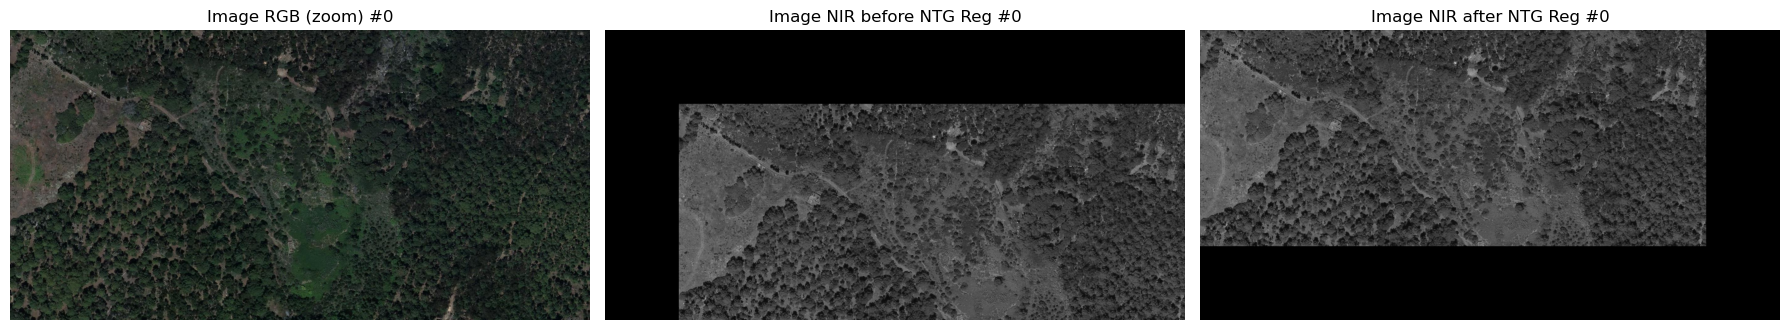

In [9]:
ntg_params_registration = []
history_ntg = []
img_NIR_warpedNTG = []
similarity_list = []

for n in range(len(img_RGB)):

    ## ------ NTG for Aerial Image Registration ------ ##
    ntg_registration_c2f, f_sim, history_c2f, ntg_warped = aerial_ImgReg_w_NTG_v0(zoom_img_list[n],img_NIR_translation[n],

                                                                            levels=4,scale_factor=2,

                                                                            # -- Barrido conjunto escala + traslación -- #
                                                                            scale_bounds=(0.02,1.05),      # zoom máximo detectable = 1/0.02 = x50
                                                                            scale_samples=160,
                                                                            scan_blur=1.0,
                                                                            scan_template_min=64,          # px mínimos de la plantilla (referencia reducida)
                                                                            scan_min_overlap=0.20,

                                                                            # -- Candidatos -- #
                                                                            topk_candidates=4,
                                                                            prune_ratio=0.10,

                                                                            # -- Refinamiento NTG por niveles -- #
                                                                            local_population=10,
                                                                            local_generations=25,
                                                                            local_scale_rel=0.03,
                                                                            delta_translation=3.00,

                                                                            # -- Overlap / máscara válida -- #
                                                                            min_overlap=0.20,
                                                                            valid_erode=2,

                                                                            seed=42
                                                                           )

    ## ------ Almacenamos los parametros, historial y warping de la toma ------ ##

    ntg_params_registration.append(ntg_registration_c2f)          # Parámetros Guardados
    history_ntg.append(history_c2f)                               # Historial de ajuste NTG
    img_NIR_warpedNTG.append(ntg_warped)                          # Warping de la imagen NIR
    similarity_list.append(f_sim)

    ## ------ Visualización y comparativa de resultados ------ ##

    plt.figure(figsize=(18,10))

    plt.subplot(1,3,1)
    plt.title(f"Image RGB (zoom) #{n}")
    plt.imshow(zoom_img_list[n])
    plt.axis('off')

    plt.subplot(1,3,2)
    plt.title(f"Image NIR before NTG Reg #{n}")
    plt.imshow(img_NIR_translation[n],cmap='gray')
    plt.axis('off')

    plt.subplot(1,3,3)
    plt.title(f"Image NIR after NTG Reg #{n}")
    plt.imshow(img_NIR_warpedNTG[n],cmap='gray')
    plt.axis('off')

    plt.tight_layout()
    plt.show()


### VALIDACIÓN CONTRA LA ABERRACIÓN APLICADA (sólo con aberraciones sintéticas)

In [10]:
## Parámetros verdaderos del modelo: u = s*x + cx*(1-s) + tx  con  s = 1/zoom, tx = tras_x, ty = tras_y
s_true, tx_true, ty_true = 1.0/zoom_factor, tras_x, tras_y

for n in range(len(img_RGB)):

    s_est, tx_est, ty_est = similarity_list[n]
    ntg_final = history_ntg[n][-1]["NTG_final"]

    print(f"Imagen #{n}")
    print(f"  Verdad    : s={s_true:.6f}  tx={tx_true:8.3f}  ty={ty_true:8.3f}   (zoom x{zoom_factor})")
    print(f"  Estimado  : s={s_est:.6f}  tx={tx_est:8.3f}  ty={ty_est:8.3f}   (zoom x{1/s_est:.4f})")
    print(f"  Error     : s={100*(s_est/s_true - 1):+.3f} %  tx={tx_est - tx_true:+.3f} px  ty={ty_est - ty_true:+.3f} px")
    print(f"  NTG final : {ntg_final:.5f}   (>0.50 suele indicar registro no convergido)")


Imagen #0
  Verdad    : s=1.000000  tx= 250.000  ty= 250.000   (zoom x1.0)
  Estimado  : s=0.999938  tx= 249.977  ty= 249.953   (zoom x1.0001)
  Error     : s=-0.006 %  tx=-0.023 px  ty=-0.047 px
  NTG final : 0.16896   (>0.50 suele indicar registro no convergido)


### DIAGNÓSTICO [PERFIL DE ESCALA DEL BARRIDO CONJUNTO Y NTG POR NIVEL]

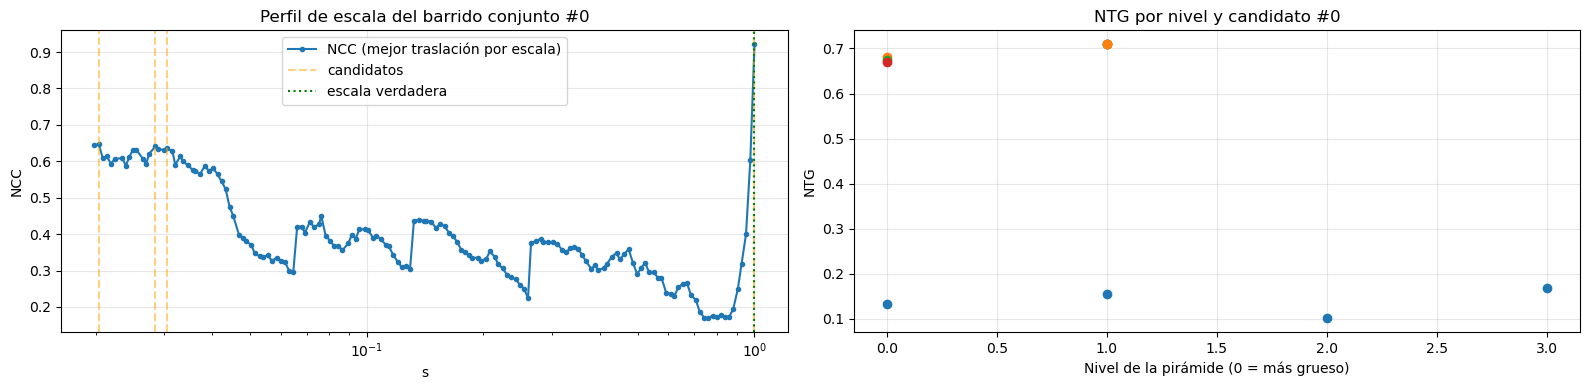

In [11]:
for n in range(len(img_RGB)):

    h = history_ntg[n]

    scan = h[0]["scan"]
    cands = h[0]["candidates"]

    s_scan = np.array([d["s"] for d in scan])
    ncc_scan = np.array([d["score"] for d in scan])

    plt.figure(figsize=(16,4))

    ## ------ Perfil NCC vs escala (cada punto ya trae su mejor traslación) ------ ##
    plt.subplot(1,2,1)
    plt.title(f"Perfil de escala del barrido conjunto #{n}")
    plt.semilogx(s_scan,ncc_scan,'.-',label='NCC (mejor traslación por escala)')
    for i, c in enumerate(cands):
        plt.axvline(c["s"],color='orange',alpha=0.5,ls='--',label='candidatos' if i == 0 else None)
    plt.axvline(1.0/zoom_factor,color='green',ls=':',label='escala verdadera')
    plt.xlabel("s"); plt.ylabel("NCC"); plt.legend(); plt.grid(alpha=0.3)

    ## ------ NTG por nivel de cada candidato ------ ##
    plt.subplot(1,2,2)
    plt.title(f"NTG por nivel y candidato #{n}")
    for level_entry in [e for e in h if e["stage"] == "local"]:
        for r in level_entry["records"]:
            plt.plot(level_entry["level"],r["ntg"],'o',color=f"C{r['id']}")
    plt.xlabel("Nivel de la pirámide (0 = más grueso)"); plt.ylabel("NTG"); plt.grid(alpha=0.3)

    plt.tight_layout()
    plt.show()


### FALSE-COLOR OVERLAY (ANTES DE NTG VS. DESPUÉS DE NTG)

In [12]:
def false_color_overlay(img_RGBgray,img_NIR,img_NIR_warped):

    def normalize_visual(img):
        
        img = img.astype(np.float32)

        min_val = np.min(img)
        max_val = np.max(img)

        return (img - min_val) / (max_val - min_val + 1e-8)

    img_RGB_ref = normalize_visual(img_RGBgray)
    img_NIR_bef_NTG = normalize_visual(img_NIR)
    img_NIR_aft_NTG = normalize_visual(img_NIR_warped)

    overlay_before = np.zeros((img_RGB_ref.shape[0],img_RGB_ref.shape[1],3),dtype=np.float32)

    overlay_after = np.zeros_like(overlay_before)

    # --- BEFORE --- #
    overlay_before[:, :, 0] = img_RGB_ref
    overlay_before[:, :, 1] = img_NIR_bef_NTG


    # --- AFTER --- #
    overlay_after[:, :, 0] = img_RGB_ref
    overlay_after[:, :, 1] = img_NIR_aft_NTG

    return overlay_before, overlay_after

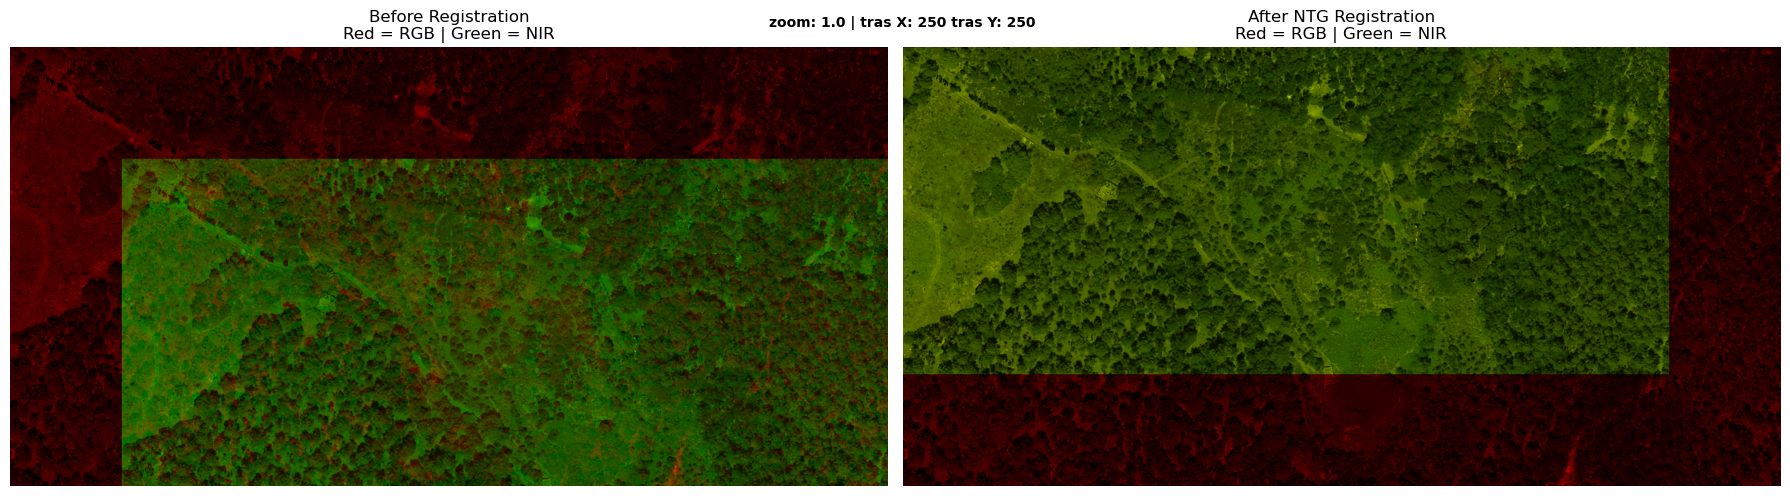

In [13]:
img_FC_before = []
img_FC_after = []

for n in range(len(img_RGB)):

    overlay_BEF_ntg, overlay_AFT_ntg = false_color_overlay(zoom_imgGRAY_list[n],img_NIR_translation[n],img_NIR_warpedNTG[n])

    img_FC_before.append(overlay_BEF_ntg)
    img_FC_after.append(overlay_AFT_ntg)
    
    plt.figure(figsize=(18,10))
    plt.figtext(0.43,0.74,f"zoom: {zoom_factor} | tras X: {tras_x} tras Y: {tras_y}",fontweight='bold')
    plt.subplot(1,2,1)
    plt.title("Before Registration\n"
              "Red = RGB | Green = NIR")
    plt.imshow(img_FC_before[n])
    plt.axis('off')

    plt.subplot(1,2,2)
    plt.title("After NTG Registration\n"
              "Red = RGB | Green = NIR")
    plt.imshow(img_FC_after[n])
    plt.axis('off')

    

    plt.tight_layout()
    plt.show()